In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt 
import cartopy 
import cmocean 
import cartopy.crs as ccrs 
import cartopy.feature as cfeature

In [2]:
norkyst_p = '/lustre/storeB/project/fou/hi/foccus/datasets/symlinks/norkystv3-hindcast/2024/norkyst800-20240402.nc'
ds = xr.open_dataset(norkyst_p)


In [3]:
import pyresample
#select an area
#lon_min, lon_max = 11.83083, 15.59072
#lat_min, lat_max = 67.41791, 69.20699

lon_ulc, lon_llc = 9.5, 9.5
lon_lrc, lon_urc = 11.5, 11.5
lat_urc, lat_ulc = 60, 60
lat_llc, lat_lrc = 58.5, 58.5

#lon_re = ds_norkyst.lon.astype(np.float64)
#lat_re = ds_norkyst.lat.astype(np.float64)

ds_grid = pyresample.geometry.GridDefinition(lons=ds.lon.values, lats = ds.lat.values)
pos_geo = pyresample.geometry.SwathDefinition(lons=[lon_llc, lon_lrc, lon_urc, lon_ulc], lats=[lat_llc, lat_lrc, lat_urc, lat_ulc])

_, valid_output_index, index_array, distance_array = pyresample.kd_tree.get_neighbour_info(
                                                    source_geo_def = ds_grid,
                                                    target_geo_def = pos_geo,
                                                    radius_of_influence = 800,
                                                    neighbours = 1)

index_array_2d = np.unravel_index(index_array, ds_grid.shape)

(x_indices,y_indices) =  np.array([index_array_2d[0][0], index_array_2d[0][1], index_array_2d[0][2], index_array_2d[0][3]]), np.array([index_array_2d[1][0], index_array_2d[1][1], index_array_2d[1][2], index_array_2d[1][3]])
x_min, x_max = x_indices.min(), x_indices.max()
y_min, y_max = y_indices.min(), y_indices.max()

#make sure its correct
print(f'X min: {x_min}, X max: {x_max}')
print(f'Y min: {y_min}, Y max: {y_max}')


X min: 108, X max: 338
Y min: 551, Y max: 805


In [4]:
def mean_nor(ds):
    mean_u_vel = ds['u_eastward'].resample(time = 'D').mean(dim = 'time')
    mean_v_vel = ds['v_northward'].resample(time = 'D').mean(dim = 'time')
    return mean_u_vel, mean_v_vel

In [5]:
ds

<xarray.Dataset> Size: 75GB
Dimensions:           (time: 24, Y: 1148, X: 2747, s_rho: 40, s_w: 41)
Coordinates:
  * time              (time) datetime64[ns] 192B 2024-04-02 ... 2024-04-02T23...
  * s_rho             (s_rho) float64 320B -0.9799 -0.9403 ... -0.004904
  * X                 (X) float64 22kB 0.0 800.0 1.6e+03 ... 2.196e+06 2.197e+06
  * Y                 (Y) float64 9kB 0.0 800.0 1.6e+03 ... 9.168e+05 9.176e+05
  * s_w               (s_w) float64 328B -1.0 -0.96 -0.9208 ... -0.01 0.0
    lon               (Y, X) float64 25MB 8.7 8.706 8.711 ... 18.29 18.31 18.33
    lat               (Y, X) float64 25MB 54.29 54.3 54.31 ... 75.71 75.72 75.73
Data variables: (12/18)
    Uwind_eastward    (time, Y, X) float32 303MB ...
    Vwind_northward   (time, Y, X) float32 303MB ...
    zeta              (time, Y, X) float32 303MB ...
    ubar_eastward     (time, Y, X) float32 303MB ...
    vbar_northward    (time, Y, X) float32 303MB ...
    u_eastward        (time, s_rho, Y, X) float32 12GB ...
    ...                ...
    hc                float64 8B ...
    Cs_r              (s_rho) float64 320B ...
    Cs_w              (s_w) float64 328B ...
    h                 (Y, X) float32 13MB ...
    projection_stere  int32 4B ...
    depth             int32 4B ...
Attributes: (12/33)
    id:                      572391bb-878e-4153-bac1-2bd854d73fe4
    naming_authority:        no.met
    operational_status:      scientific
    iso_topic_category:      oceans
    activity_type:           Numerical Simulation
    keywords_vocabulary:     GCMDSK:GCMD Science Keywords:https://gcmd.earthd...
    ...                      ...
    project:                 Norkyst_v3
    license:                 https://spdx.org/licenses/CC-BY-4.0 (CC-BY-4.0)
    title:                   Norkyst-800m - ROMS, Norkyst-800m ocean hindcast...
    summary:                 Norkyst-800m (Norwegian Coast 800m horizontal re...
    title_no:                Hindcast prognoser fra havmodellen Norkyst-800m,...
    summary_no:              NorKyst-800m (Norske kystområder med 800m horiso...

In [6]:
ds_norkyst_lof = ds.isel(Y=slice(310, 1057+1), X = slice(1466, 2271 +1))
ds_norkyst_lof

<xarray.Dataset> Size: 14GB
Dimensions:           (time: 24, Y: 748, X: 806, s_rho: 40, s_w: 41)
Coordinates:
  * time              (time) datetime64[ns] 192B 2024-04-02 ... 2024-04-02T23...
  * s_rho             (s_rho) float64 320B -0.9799 -0.9403 ... -0.004904
  * X                 (X) float64 6kB 1.173e+06 1.174e+06 ... 1.817e+06
  * Y                 (Y) float64 6kB 2.48e+05 2.488e+05 ... 8.448e+05 8.456e+05
  * s_w               (s_w) float64 328B -1.0 -0.96 -0.9208 ... -0.01 0.0
    lon               (Y, X) float64 5MB 16.01 16.02 16.03 ... 12.73 12.75 12.76
    lat               (Y, X) float64 5MB 64.36 64.37 64.37 ... 72.4 72.41 72.42
Data variables: (12/18)
    Uwind_eastward    (time, Y, X) float32 58MB ...
    Vwind_northward   (time, Y, X) float32 58MB ...
    zeta              (time, Y, X) float32 58MB ...
    ubar_eastward     (time, Y, X) float32 58MB ...
    vbar_northward    (time, Y, X) float32 58MB ...
    u_eastward        (time, s_rho, Y, X) float32 2GB ...
    ...                ...
    hc                float64 8B ...
    Cs_r              (s_rho) float64 320B ...
    Cs_w              (s_w) float64 328B ...
    h                 (Y, X) float32 2MB ...
    projection_stere  int32 4B ...
    depth             int32 4B ...
Attributes: (12/33)
    id:                      572391bb-878e-4153-bac1-2bd854d73fe4
    naming_authority:        no.met
    operational_status:      scientific
    iso_topic_category:      oceans
    activity_type:           Numerical Simulation
    keywords_vocabulary:     GCMDSK:GCMD Science Keywords:https://gcmd.earthd...
    ...                      ...
    project:                 Norkyst_v3
    license:                 https://spdx.org/licenses/CC-BY-4.0 (CC-BY-4.0)
    title:                   Norkyst-800m - ROMS, Norkyst-800m ocean hindcast...
    summary:                 Norkyst-800m (Norwegian Coast 800m horizontal re...
    title_no:                Hindcast prognoser fra havmodellen Norkyst-800m,...
    summary_no:              NorKyst-800m (Norske kystområder med 800m horiso...

In [7]:
ds_norkyst_sula = ds.isel(Y=slice(560, 849+1), X = slice(814, 1050 +1))
ds_norkyst_sula

<xarray.Dataset> Size: 2GB
Dimensions:           (time: 24, Y: 290, X: 237, s_rho: 40, s_w: 41)
Coordinates:
  * time              (time) datetime64[ns] 192B 2024-04-02 ... 2024-04-02T23...
  * s_rho             (s_rho) float64 320B -0.9799 -0.9403 ... -0.004904
  * X                 (X) float64 2kB 6.512e+05 6.52e+05 ... 8.392e+05 8.4e+05
  * Y                 (Y) float64 2kB 4.48e+05 4.488e+05 ... 6.784e+05 6.792e+05
  * s_w               (s_w) float64 328B -1.0 -0.96 -0.9208 ... -0.01 0.0
    lon               (Y, X) float64 550kB 7.196 7.202 7.209 ... 4.733 4.74
    lat               (Y, X) float64 550kB 61.27 61.27 61.28 ... 63.72 63.73
Data variables: (12/18)
    Uwind_eastward    (time, Y, X) float32 7MB ...
    Vwind_northward   (time, Y, X) float32 7MB ...
    zeta              (time, Y, X) float32 7MB ...
    ubar_eastward     (time, Y, X) float32 7MB ...
    vbar_northward    (time, Y, X) float32 7MB ...
    u_eastward        (time, s_rho, Y, X) float32 264MB ...
    ...                ...
    hc                float64 8B ...
    Cs_r              (s_rho) float64 320B ...
    Cs_w              (s_w) float64 328B ...
    h                 (Y, X) float32 275kB ...
    projection_stere  int32 4B ...
    depth             int32 4B ...
Attributes: (12/33)
    id:                      572391bb-878e-4153-bac1-2bd854d73fe4
    naming_authority:        no.met
    operational_status:      scientific
    iso_topic_category:      oceans
    activity_type:           Numerical Simulation
    keywords_vocabulary:     GCMDSK:GCMD Science Keywords:https://gcmd.earthd...
    ...                      ...
    project:                 Norkyst_v3
    license:                 https://spdx.org/licenses/CC-BY-4.0 (CC-BY-4.0)
    title:                   Norkyst-800m - ROMS, Norkyst-800m ocean hindcast...
    summary:                 Norkyst-800m (Norwegian Coast 800m horizontal re...
    title_no:                Hindcast prognoser fra havmodellen Norkyst-800m,...
    summary_no:              NorKyst-800m (Norske kystområder med 800m horiso...

In [8]:
ds_norkyst_oslo = ds.isel(Y=slice(108, 338+1), X = slice(551, 805 +1))
ds_norkyst_oslo

<xarray.Dataset> Size: 1GB
Dimensions:           (time: 24, Y: 231, X: 255, s_rho: 40, s_w: 41)
Coordinates:
  * time              (time) datetime64[ns] 192B 2024-04-02 ... 2024-04-02T23...
  * s_rho             (s_rho) float64 320B -0.9799 -0.9403 ... -0.004904
  * X                 (X) float64 2kB 4.408e+05 4.416e+05 ... 6.432e+05 6.44e+05
  * Y                 (Y) float64 2kB 8.64e+04 8.72e+04 ... 2.696e+05 2.704e+05
  * s_w               (s_w) float64 328B -1.0 -0.96 -0.9208 ... -0.01 0.0
    lon               (Y, X) float64 471kB 10.98 10.99 10.99 ... 10.0 10.01
    lat               (Y, X) float64 471kB 58.04 58.05 58.06 ... 60.44 60.44
Data variables: (12/18)
    Uwind_eastward    (time, Y, X) float32 6MB ...
    Vwind_northward   (time, Y, X) float32 6MB ...
    zeta              (time, Y, X) float32 6MB ...
    ubar_eastward     (time, Y, X) float32 6MB ...
    vbar_northward    (time, Y, X) float32 6MB ...
    u_eastward        (time, s_rho, Y, X) float32 226MB ...
    ...                ...
    hc                float64 8B ...
    Cs_r              (s_rho) float64 320B ...
    Cs_w              (s_w) float64 328B ...
    h                 (Y, X) float32 236kB ...
    projection_stere  int32 4B ...
    depth             int32 4B ...
Attributes: (12/33)
    id:                      572391bb-878e-4153-bac1-2bd854d73fe4
    naming_authority:        no.met
    operational_status:      scientific
    iso_topic_category:      oceans
    activity_type:           Numerical Simulation
    keywords_vocabulary:     GCMDSK:GCMD Science Keywords:https://gcmd.earthd...
    ...                      ...
    project:                 Norkyst_v3
    license:                 https://spdx.org/licenses/CC-BY-4.0 (CC-BY-4.0)
    title:                   Norkyst-800m - ROMS, Norkyst-800m ocean hindcast...
    summary:                 Norkyst-800m (Norwegian Coast 800m horizontal re...
    title_no:                Hindcast prognoser fra havmodellen Norkyst-800m,...
    summary_no:              NorKyst-800m (Norske kystområder med 800m horiso...

In [9]:
ds_norkyst_ocean = ds.isel(Y=slice(783, 1090+1), X = slice(2430, 2744 +1))
ds_norkyst_ocean

<xarray.Dataset> Size: 2GB
Dimensions:           (time: 24, Y: 308, X: 315, s_rho: 40, s_w: 41)
Coordinates:
  * time              (time) datetime64[ns] 192B 2024-04-02 ... 2024-04-02T23...
  * s_rho             (s_rho) float64 320B -0.9799 -0.9403 ... -0.004904
  * X                 (X) float64 3kB 1.944e+06 1.945e+06 ... 2.195e+06
  * Y                 (Y) float64 2kB 6.264e+05 6.272e+05 ... 8.712e+05 8.72e+05
  * s_w               (s_w) float64 328B -1.0 -0.96 -0.9208 ... -0.01 0.0
    lon               (Y, X) float64 776kB 20.52 20.53 20.55 ... 19.62 19.64
    lat               (Y, X) float64 776kB 72.15 72.15 72.16 ... 75.44 75.44
Data variables: (12/18)
    Uwind_eastward    (time, Y, X) float32 9MB ...
    Vwind_northward   (time, Y, X) float32 9MB ...
    zeta              (time, Y, X) float32 9MB ...
    ubar_eastward     (time, Y, X) float32 9MB ...
    vbar_northward    (time, Y, X) float32 9MB ...
    u_eastward        (time, s_rho, Y, X) float32 373MB ...
    ...                ...
    hc                float64 8B ...
    Cs_r              (s_rho) float64 320B ...
    Cs_w              (s_w) float64 328B ...
    h                 (Y, X) float32 388kB ...
    projection_stere  int32 4B ...
    depth             int32 4B ...
Attributes: (12/33)
    id:                      572391bb-878e-4153-bac1-2bd854d73fe4
    naming_authority:        no.met
    operational_status:      scientific
    iso_topic_category:      oceans
    activity_type:           Numerical Simulation
    keywords_vocabulary:     GCMDSK:GCMD Science Keywords:https://gcmd.earthd...
    ...                      ...
    project:                 Norkyst_v3
    license:                 https://spdx.org/licenses/CC-BY-4.0 (CC-BY-4.0)
    title:                   Norkyst-800m - ROMS, Norkyst-800m ocean hindcast...
    summary:                 Norkyst-800m (Norwegian Coast 800m horizontal re...
    title_no:                Hindcast prognoser fra havmodellen Norkyst-800m,...
    summary_no:              NorKyst-800m (Norske kystområder med 800m horiso...

In [10]:
u_nor_lof, v_nor_lof = mean_nor(ds_norkyst_lof)
u_nor_sula, v_nor_sula = mean_nor(ds_norkyst_sula)
u_nor_oslo, v_nor_oslo = mean_nor(ds_norkyst_oslo)
u_nor_ocean, v_nor_ocean = mean_nor(ds_norkyst_ocean)

#Regne ut f/h
h_nor = ds.h
omega = 7.2921e-5
lat_nor = ds.lat
lat_nor_rad = np.deg2rad(lat_nor)
f_nor = 2 * omega * np.sin(lat_nor_rad)
fh_nor_vals = f_nor/h_nor

In [11]:
def f_h_norkyst(ds):
    #Regne ut f/h
    h = ds.h
    omega = 7.2921e-5
    lat_nor = ds.lat
    lat_nor_rad = np.deg2rad(lat_nor)
    f_nor = 2 * omega * np.sin(lat_nor_rad)
    f_h = f_nor/h
    return f_h 

In [12]:
ds_norkyst_lof

<xarray.Dataset> Size: 14GB
Dimensions:           (time: 24, Y: 748, X: 806, s_rho: 40, s_w: 41)
Coordinates:
  * time              (time) datetime64[ns] 192B 2024-04-02 ... 2024-04-02T23...
  * s_rho             (s_rho) float64 320B -0.9799 -0.9403 ... -0.004904
  * X                 (X) float64 6kB 1.173e+06 1.174e+06 ... 1.817e+06
  * Y                 (Y) float64 6kB 2.48e+05 2.488e+05 ... 8.448e+05 8.456e+05
  * s_w               (s_w) float64 328B -1.0 -0.96 -0.9208 ... -0.01 0.0
    lon               (Y, X) float64 5MB 16.01 16.02 16.03 ... 12.73 12.75 12.76
    lat               (Y, X) float64 5MB 64.36 64.37 64.37 ... 72.4 72.41 72.42
Data variables: (12/18)
    Uwind_eastward    (time, Y, X) float32 58MB ...
    Vwind_northward   (time, Y, X) float32 58MB ...
    zeta              (time, Y, X) float32 58MB ...
    ubar_eastward     (time, Y, X) float32 58MB ...
    vbar_northward    (time, Y, X) float32 58MB ...
    u_eastward        (time, s_rho, Y, X) float32 2GB ...
    ...                ...
    hc                float64 8B ...
    Cs_r              (s_rho) float64 320B ...
    Cs_w              (s_w) float64 328B ...
    h                 (Y, X) float32 2MB ...
    projection_stere  int32 4B ...
    depth             int32 4B ...
Attributes: (12/33)
    id:                      572391bb-878e-4153-bac1-2bd854d73fe4
    naming_authority:        no.met
    operational_status:      scientific
    iso_topic_category:      oceans
    activity_type:           Numerical Simulation
    keywords_vocabulary:     GCMDSK:GCMD Science Keywords:https://gcmd.earthd...
    ...                      ...
    project:                 Norkyst_v3
    license:                 https://spdx.org/licenses/CC-BY-4.0 (CC-BY-4.0)
    title:                   Norkyst-800m - ROMS, Norkyst-800m ocean hindcast...
    summary:                 Norkyst-800m (Norwegian Coast 800m horizontal re...
    title_no:                Hindcast prognoser fra havmodellen Norkyst-800m,...
    summary_no:              NorKyst-800m (Norske kystområder med 800m horiso...

In [13]:
print(u_nor_lof.shape)
print(ds_norkyst_lof.X.shape)

(1, 40, 748, 806)
(806,)


In [ ]:
def fh_nor(area, fh, u_vel, v_vel, title, step = 5, min_l = -0.5e-5, max_l = 1.44e-5):
    fig, ax = plt.subplots(figsize = (10,12), subplot_kw={'projection' : ccrs.NorthPolarStereo()})
    step = step
    min_l = min_l
    max_l = max_l
    custom = np.linspace(min_l, max_l, 20)
    im = ax.contour(area.lon.values, area.lat.values, fh[:,:], levels = custom, transform = ccrs.PlateCarree(), zorder = 2, color = 'black')
    im_fill = ax.contourf(area.lon.values, area.lat.values, fh[:,:], levels = custom, transform = ccrs.PlateCarree(), zorder = 1, cmap = cmocean.cm.topo)
    ax.quiver(area.lon.values[::step, ::step], area.lat.values[::step, ::step], u_vel[0,-1,:,:].values[::step, ::step], v_vel[0,-1,:,:].values[::step, ::step], transform = ccrs.PlateCarree(), color = 'black', alpha = 0.6, scale = 30)
    cax = fig.add_axes([ax.get_position().x1+0.025, ax.get_position().y0, 0.025, ax.get_position().height])
    cbar = fig.colorbar(im_fill, ax=ax, cax = cax, extend = 'both')
    cbar.ax.set_title(r'$\frac{f}{h}$')
    gl = ax.gridlines(crs = ccrs.PlateCarree(), draw_labels = True, linewidth = 1, color = 'black', alpha = 0.1, linestyle = '--')
    gl.xlabels_top = False 
    gl.ylabels_right = False 
    ax.set_title(f'{title}')
    ax.add_feature(cartopy.feature.LAND, zorder = 1, edgecolor = 'black')
    plt.show()


In [22]:
fh_lof = f_h_norkyst(ds_norkyst_lof)
fh_sula = f_h_norkyst(ds_norkyst_sula)
fh_oslo = f_h_norkyst(ds_norkyst_oslo)
fh_ocean = f_h_norkyst(ds_norkyst_ocean)

/lustre/storeB/project/fou/hi/foccus/.venv/lib64/python3.11/site-packages/cartopy/mpl/geoaxes.py:1600: UserWarning: The following kwargs were not used by contour: 'color'
  result = super().contour(*args, **kwargs)


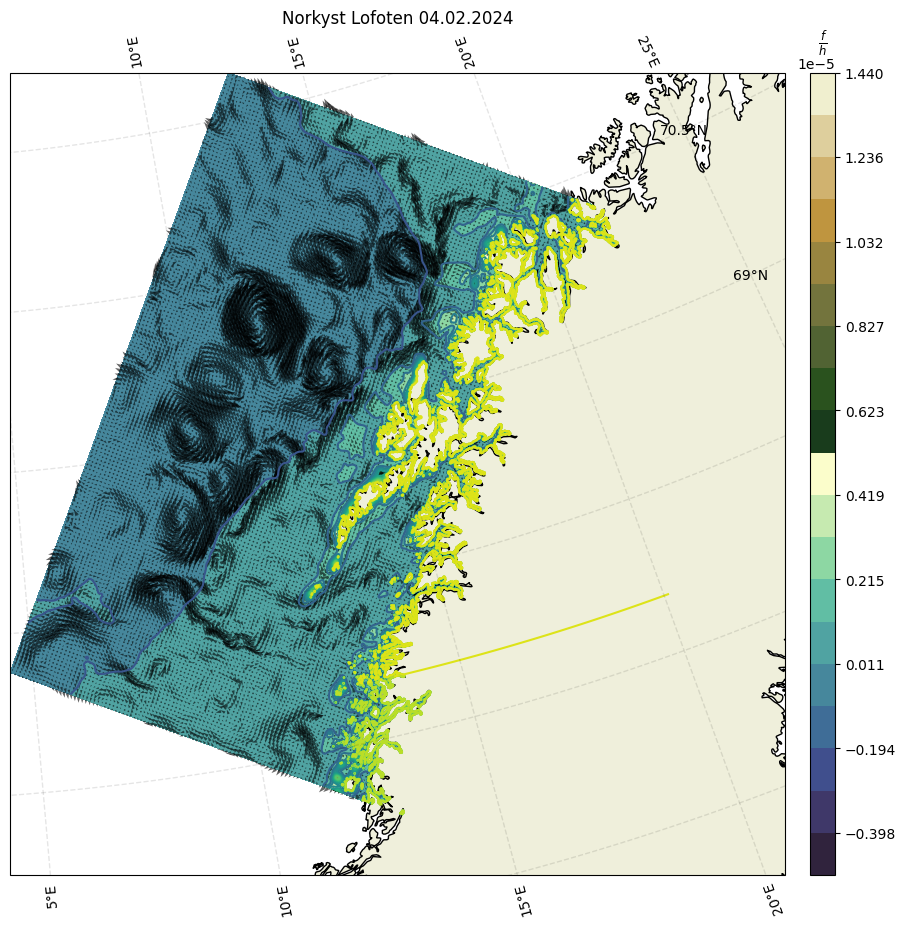

In [23]:
fh_nor(ds_norkyst_lof, fh_lof, u_nor_lof, v_nor_lof, 'Norkyst Lofoten 04.02.2024')

/lustre/storeB/project/fou/hi/foccus/.venv/lib64/python3.11/site-packages/cartopy/mpl/geoaxes.py:1600: UserWarning: The following kwargs were not used by contour: 'color'
  result = super().contour(*args, **kwargs)


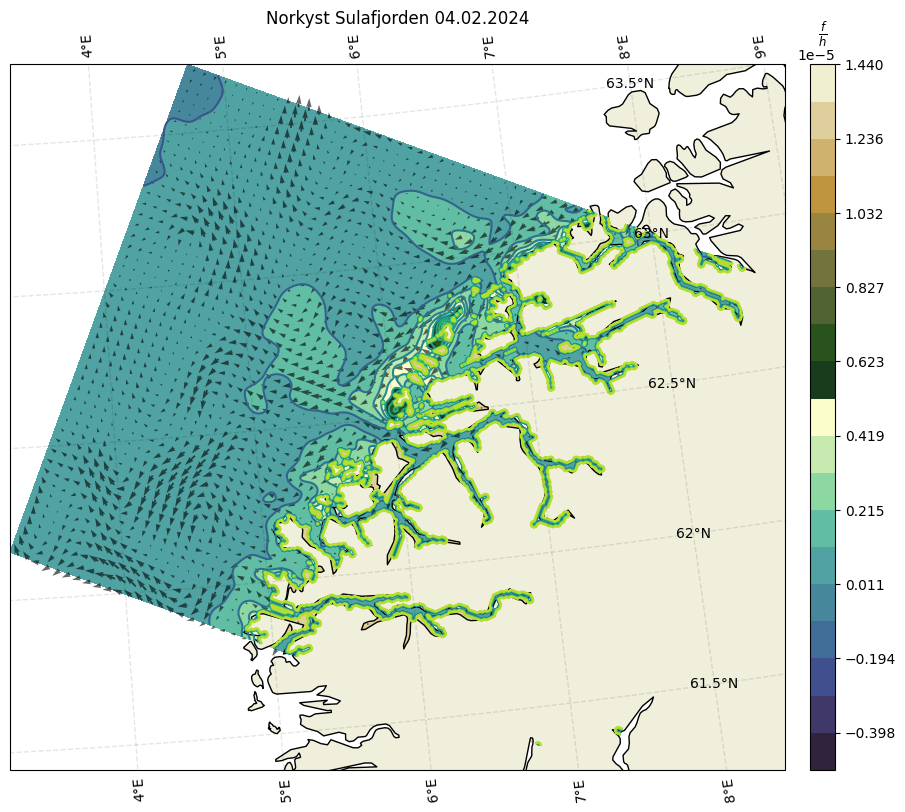

In [24]:
fh_nor(ds_norkyst_sula, fh_sula, u_nor_sula, v_nor_sula, 'Norkyst Sulafjorden 04.02.2024')

/lustre/storeB/project/fou/hi/foccus/.venv/lib64/python3.11/site-packages/cartopy/mpl/geoaxes.py:1600: UserWarning: The following kwargs were not used by contour: 'color'
  result = super().contour(*args, **kwargs)


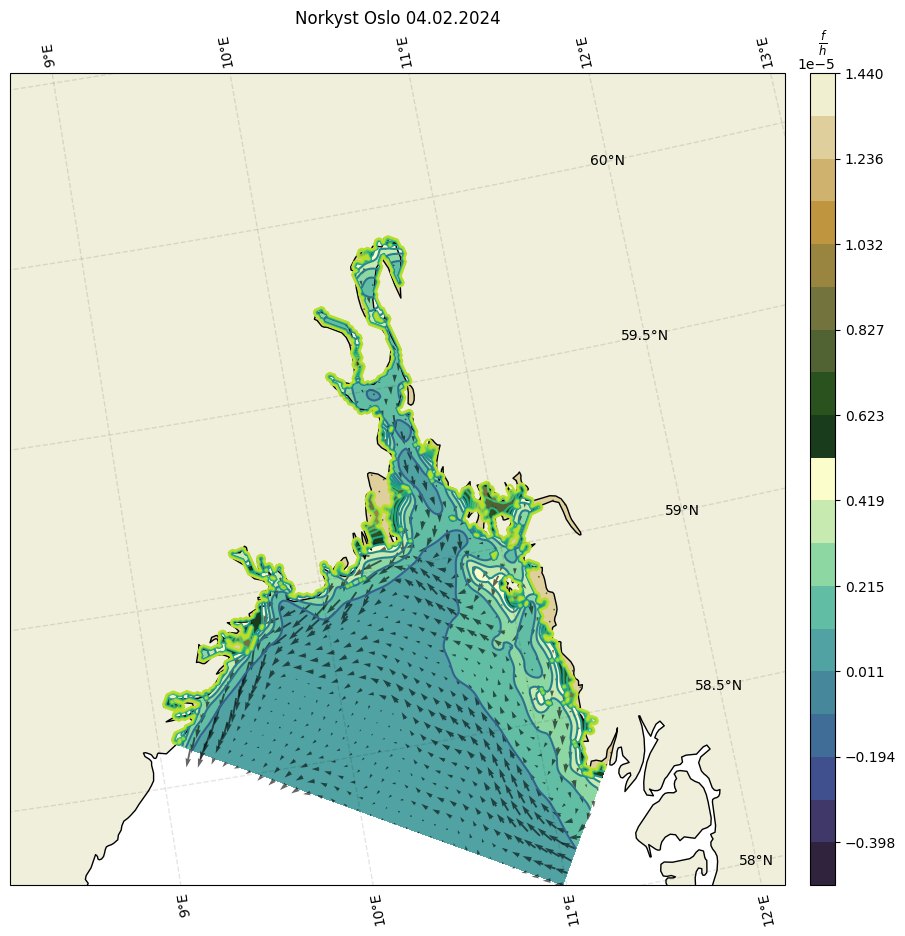

In [25]:
fh_nor(ds_norkyst_oslo, fh_oslo, u_nor_oslo, v_nor_oslo, 'Norkyst Oslo 04.02.2024')

/lustre/storeB/project/fou/hi/foccus/.venv/lib64/python3.11/site-packages/cartopy/mpl/geoaxes.py:1600: UserWarning: The following kwargs were not used by contour: 'color'
  result = super().contour(*args, **kwargs)


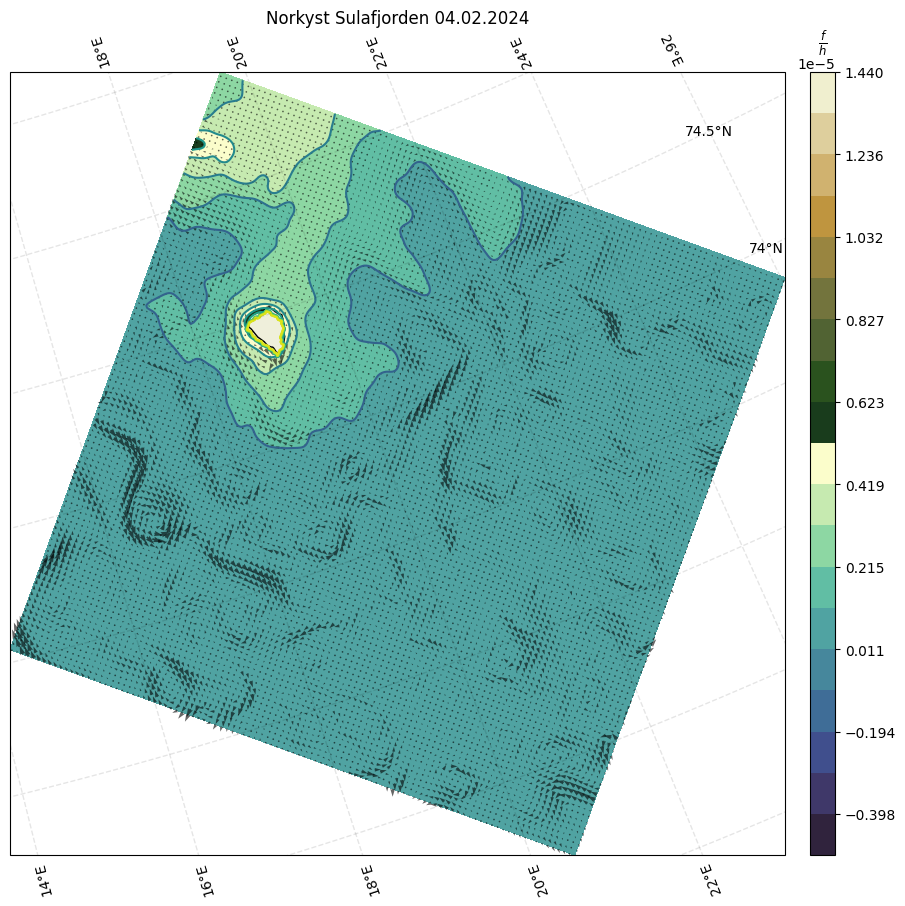

In [26]:
fh_nor(ds_norkyst_ocean, fh_ocean, u_nor_ocean, v_nor_ocean, 'Norkyst Sulafjorden 04.02.2024', step = 3)